# Nanobanana Filter — Prompt Playground

Iterate on prompts and models using the same generation code as `filter_nanobanana.py`.

**Workflow:** Edit the **Config** cell (model, prompt, image path), then re-run **Generate & Display**.

In [50]:
import base64
import io
import os

import requests

# Load API key from environment (or .env file in this directory)
from dotenv import load_dotenv
from IPython.display import display
from PIL import Image

load_dotenv()

GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY")
assert GEMINI_API_KEY, "Set GEMINI_API_KEY in your environment or .env file"

# ---------------------------------------------------------------------------
# Available models (from model_catalog.py)
# ---------------------------------------------------------------------------
MODELS = {
    "gemini-2.5-flash-image": {"image_sizes": ()},
    "gemini-3-pro-image": {"image_sizes": ("1K", "2K", "4K")},
    "gemini-3.1-flash-image": {"image_sizes": ("512", "1K", "2K", "4K")},
    "gemini-3.1-flash-lite-image": {"image_sizes": ("512", "1K", "2K", "4K")}
}

print(f"API key loaded. Available models: {list(MODELS.keys())}")

API key loaded. Available models: ['gemini-2.5-flash-image', 'gemini-3-pro-image', 'gemini-3.1-flash-image', 'gemini-3.1-flash-lite-image']


In [ ]:
# ---------------------------------------------------------------------------
# Style prompts from production config — use as STYLES["name"] for the prompt
# ---------------------------------------------------------------------------
STYLES = {
    # OK - Gemini 3.1 Flash Image
    "1996": """Keep framing and faces unchanged. Dress the people in typical 1990s attire (oversized T-Shirts, colorful windbreakers, flannel shirts etc.). In the style of a throw-away film camera photo and imprint the date 08.10.1996 in the style of 90s disposable cameras. Maintain their exact faces and poses.""",
    # OK - Gemini 3.1 Flash Image
    "kaleidoscope": "Symmetrical kaleidoscope portrait effect, repeating geometric mirror patterns while keeping the subject's face fully recognizable and centered.",
    # OK - Gemini 3.1 Flash Image
    "ghibli": "Redraw this in the style of Studio Ghibli. Make older people look a bit younger than they are.",
    # OK - Gemini 3.1 Flash Image
    "jojo": "Redraw this portrait in the style of the new anime version of Jojo's Bizarre Adventure, while keeping the facial features and hair of the people mostly unchanged. Slightly exaggerate the poses and use vibrant colors with thick lines and stylized text.",
    # Ok, but looks shitty
    "cartoon": "Transform this portrait into a cartoon style, animated, colorful, disney-like illustration",
    # OK - Gemini 3.1 Flash Image
    "sketch": "Pencil sketch, black and white drawing, artistic sketch. Keep people recognizable and maintain their poses.",
    # OK - Gemini 3.1 Flash Image
    "watercolor": "Watercolor painting, soft brush strokes, artistic.",
    # OK - Gemini 3.1 Flash Image
    "vintage": "Transform this portrait to vintage photography style, sepia tones, retro aesthetic",
    # OK+ - Gemini 3.1 Flash Image
    "barbie": "Redraw this portrait in the style of Mattel's Barbie, vibrant colors, fashionable outfits, and playful aesthetic. Make everyone plastic, but keep poses and framing.",
    # OK - Gemini 3.1 Flash Image
    "fantasy": 'Photorealistic Elven style transfer. Keep subject\'s features and background geometry 1:1, but dress the subject(s) in fancy elven clothes. Adjust lighting to be low-contrast and ethereal. Add "The Fellowship of the Ring" film grain and color palette. Subtle elven ear modification. High-end fantasy film aesthetic, soft romantic lighting, shimmering highlights, 8k resolution, cinematic bloom.',
    # OK - Gemini 3.1 Flash Image
    "dragonball": "Redraw this in the style of Classic Dragon Ball by Akira Toriyama, don't change the subjects features and poses too much. Clean, bold anime style with sharp linework, simple but expressive faces with the typical Toriyama eyes, large spiky hair and strong silhouettes. Bright, flat colors with minimal shading, clear outlines, and a playful yet powerful tone. Characters appear energetic and iconic, with a mix of humor and intense martial-arts action.",
    # OK - Gemini 3.1 Flash Image
    "pixar": "Redraw this portrait in Pixar animation style, 3D rendered appearance, colorful and friendly",
    # OK - Gemini 3.1 Flash Image
    "ken": "Redraw this in a hyper-detailed 1980s retro anime style, 'Fist of the North Star' aesthetic. Men are depicted with extreme muscular hypertrophy, defined deltoids, and rugged, scarred features. Women are drawn with ethereal elegance, large expressive eyes, and soft porcelain skin. Character poses are dramatic and high-tension with heavy black ink cross-hatching and intense 'Gekiga' line work. Dramatic high-contrast shadows, cinematic desert wasteland lighting, 8mm film grain texture.",
    # OK - Gemini 3.1 Flash Image
    "tattoo": "Make the people in the photo look like Yakuza, show their tattoos prominently, but avoid face tatoos. Remember, NO face tattoos. Keep their faces, poses, and expressions unchanged. Do not add or remove people!",
    # OK - Gemini 3.1 Flash Image
    "mountain": "Put the people on a mountain top, wearing hiking gear and backpacks. Keep their faces, poses, and expressions unchanged. Draw it in a realistic style. Do not add or remove people!",
    # OK - Gemini 3.1 Flash Image, Almost OK - Gemini 3.1 Flash Lite Image
    "chibi_musicians": "Put all the people in the image on a music stage, playing instruments, while keeping their faces and expressions recognizable and the poses unchanged. Do it in a chibi cute anime style.",
    # OK - Gemini 3.1 Flash Image, Almost almost OK - Gemini 3.1 Flash Lite Image
    "lego": "Redraw this portrait in the style of LEGO minifigures, keeping the subjects' facial features and poses recognizable. Use bright, blocky colors and maintain the iconic LEGO aesthetic.",
    # OK - Gemini 3.1 Flash Image
    "8-bit": "Redraw all people as a JRPG 8-bit party top-down view. Keep them recognizable but draw them in a pixalated 8-bit style. Don't add names to the characters.",
    # OK (for few people) - Gemini 3.1 Flash Image
    "impressionist": "Redraw this portrait in the style of Impressionist painters like Claude Monet, Van Gogh or Pierre-Auguste Renoir, with visible brushstrokes, soft lighting, and a focus on capturing the overall atmosphere rather than fine details."}

In [415]:
# Not OK prompts
not_working = {
    # Not OK - Prohibited Content - Gemini 3.1 Flash Image
    "starwars": "Transform the portrait into a Star Wars Movie poster, make all people look like from the original Star Wars with nice 70s hair and the proper clothing. If possible give one of them a Lightsaber.",
    }

In [ ]:
#Wedding_Prompts = {
#        "4-vacation": "Dress the people in vacation attire, including umbrellas, sunglasses and hats. Maintain their exact faces and poses.",
#        "5-bachelor-party": "Put the people into a bachelor party scene, with flashing lights, confetti, videogames (PS4) and baskets of stuff to sell. They all wear party hats. Keep their faces and poses unchanged.",
#        "6-vacation-2": "Apply a light filter that overlays a semi-transparent collage of passport entry stamps from different countries (e.g., Austria, Italy, Spain, Thailand) across the image and some airplanes and trains, *avoiding* covering the people's faces. Keep the subjects and background unchanged.",
#        "7-train": "Put old-fashioned train conductors hats on all the people in the image and put a steam-powered train into the background. Keep their faces, poses, and expressions unchanged. Do not add or remove people!",
#        "8-car": "Make all the people in the image sit on their own small kid's toy car. Keep their faces and expressions unchanged, but adapt their poses to fit them in the car. Do not add or remove people!",
#        "9-hairstyle": "Make all people in the photo bald and add a sparkle to their head. Keep their faces (including beards), poses, and expressions unchanged. Do not add or remove people!",
#        "10-200km": "Make all the people in the image look like adventurers and travelers with dirty and worn clothes. They wear backpacks and heavy traveling boots. The person in the middle holds a map and a compass. Keep their faces, poses, and expressions as well as the background unchanged. Do not add or remove people!",
#        "11-pet": "Add photorealistic pet dinosaurs on a leash to each person. Add one T-Rex in the background trying to fit the frame. Keep their faces, poses, and expressions unchanged, but adapt the poses if necessary to have them sit in their chairs. Do not add or remove people!",
#        "12-teacher": "Redraw the image in an anime style, with the people dressed as students in a classroom setting. Keep their faces, poses, and expressions recognizable. Do not add or remove people!",
#        "13-musicians": "Put all the people in the image on a music stage, playing instruments, while keeping their faces, poses, and expressions recognizable. Do it in a chibi cute anime style.",
#        "14-endurance": "Put the people on a track and field racing track. They are wearing sportswear and running shoes. Keep their faces, and expressions recognizable. Draw it in a black and white sketch like style. Do not add or remove people!",
#        "15-mountain": "Put the people on a mountain top, wearing hiking gear and backpacks. Keep their faces, poses, and expressions unchanged. Draw it in a realistic style. Do not add or remove people!",
#        "16-spicy": "Make all the people in the image spit fire as they ate extremely spicy food. They are sweaty and red but happy. Do not add or remove people!",
#        "17-virgo": "Make all the people in the image look like fair men or women dressed like the zodiac sign Virgo. Put them in white tunicas and give them flowing beautiful hair. Keep their faces, poses, and expressions unchanged. Do not add or remove people!",
#        "20-glasses": "Give all the people in the image googly eyes. Keep their faces, poses, and expressions unchanged. Do not add or remove people!",
#        "21-multilingual": "Add speech bubbles to the top of the peoples heads in the image, saying funny things in a different language (Japanese, Chinese, English, Spanish, German, Italian). Keep their faces, poses, and expressions unchanged. Do not add or remove people!",
#        "22-aries": "Give all people in the piture horns like a ram. Keep their faces, poses, and expressions unchanged. Do not add or remove people!",
#        "23-tatoo": "Make the people in the photo look like Yakuza, show their tattoos prominently, but avoid face tatoos. Remember, NO face tattoos. Keep their faces, poses, and expressions unchanged. Do not add or remove people!",
#        "24-series": "Put the people inside of a TV and make it look like romantic NETFLIX TV show titled 'Wedding Season'. Avoid changing their faces, poses or expressions. Do not add or remove people!",
#        "25-gamers": "Put all the people in this image into a 2D side-scroller beat 'em up video game scene. Make them all fight a godzilla with a bride veil. Keep them recognizable but draw them in a pixalated 8-bit style. Don't add names to the characeters, only the bridezilla healthbar should have a name.",
#        "26-japan": "Modify only the clothing of the people in the image. Change their current outfits into traditional Japanese kimonos or yukatas. Crucially, do not alter, remove, or replace any people. Keep all faces, identical facial expressions, body poses, and the background exactly as they are in the original image.",
#}

In [417]:
print(f"Available styles: {list(STYLES.keys())}")

Available styles: ['1996', 'kaleidoscope', 'ghibli', 'jojo', 'cartoon', 'sketch', 'watercolor', 'vintage', 'barbie', 'fantasy', 'dragonball', 'pixar', 'ken', 'tatoo', 'mountain', 'chibi_musicians', 'lego', '8-bit', 'impressionist']


## Config — edit this cell and re-run Generate

Pick a **model** (just type the short name), set the **prompt** (or use a style), and point to your **image**.

In [421]:
# ── Model ────────────────────────────────────────────────────────────────
# Just type the short name: "gemini-2.5-flash-image", "gemini-3-pro-image", "gemini-3.1-flash-image"
model = "gemini-3.1-flash-image"

# ── Prompt ───────────────────────────────────────────────────────────────
# Use a style:  prompt = STYLES["anime"]
# Or write your own:
prompt = STYLES["impressionist"]
# prompt = "Modify the image so all people are wearing kimonos or traditional japanese clothing and optionally add some Japanese stuff in the background (e.g. a Torii gate); make sure not to change their faces!"

# ── Image ────────────────────────────────────────────────────────────────
# image_path = '/Users/clang88/Desktop/5 - Gruppen und Abschluss-0050.jpg'
image_path = "/Users/clang88/Desktop/camera_original_2026-07-03T18-12-42_(2)_preview.jpeg"
#image_path = "/Users/clang88/Desktop/camera_raw_2026-07-03T17-15-28_(2)_preview.jpeg"
# ── Generation settings (matching production defaults) ───────────────────
input_image_format = "jpeg"  # "jpeg" | "png" | "webp"
aspect_ratio = "3:2"  # 1:1, 2:3, 3:2, 3:4, 4:3, 4:5, 5:4, 9:16, 16:9, 21:9
image_size = "1K"  # "512" | "1K" | "2K" | "4K" (not all models support all sizes)
max_input_size = 2048  # max dimension before sending to API
response_modalities = ["IMAGE"]  # ["IMAGE"] or ["TEXT", "IMAGE"]
timeout_seconds = 300

print(f"Model: {model}")
print(f"Prompt: {prompt[:80]}{'...' if len(prompt) > 80 else ''}")
print(f"Image:  {image_path}")

Model: gemini-3.1-flash-image
Prompt: Redraw this portrait in the style of Impressionist painters like Claude Monet, V...
Image:  /Users/clang88/Desktop/camera_original_2026-07-03T18-12-42_(2)_preview.jpeg


In [422]:
from datetime import datetime

# Determine style key or "custom"
_style_key = next((k for k, v in STYLES.items() if v == prompt), "custom")
# Strip "-image" suffix from model name for brevity
_model_short = model.replace("-image", "")
_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

output_filename = f"{_style_key}_{_model_short}_{_timestamp}.png"
print(f"Output filename: {output_filename}")

Output filename: impressionist_gemini-3.1-flash_2026-09-13_21-21-47.png


Resized to (2048, 1365)
Sending request to gemini-3.1-flash-image...
Generated image: (1264, 848), mode=RGB


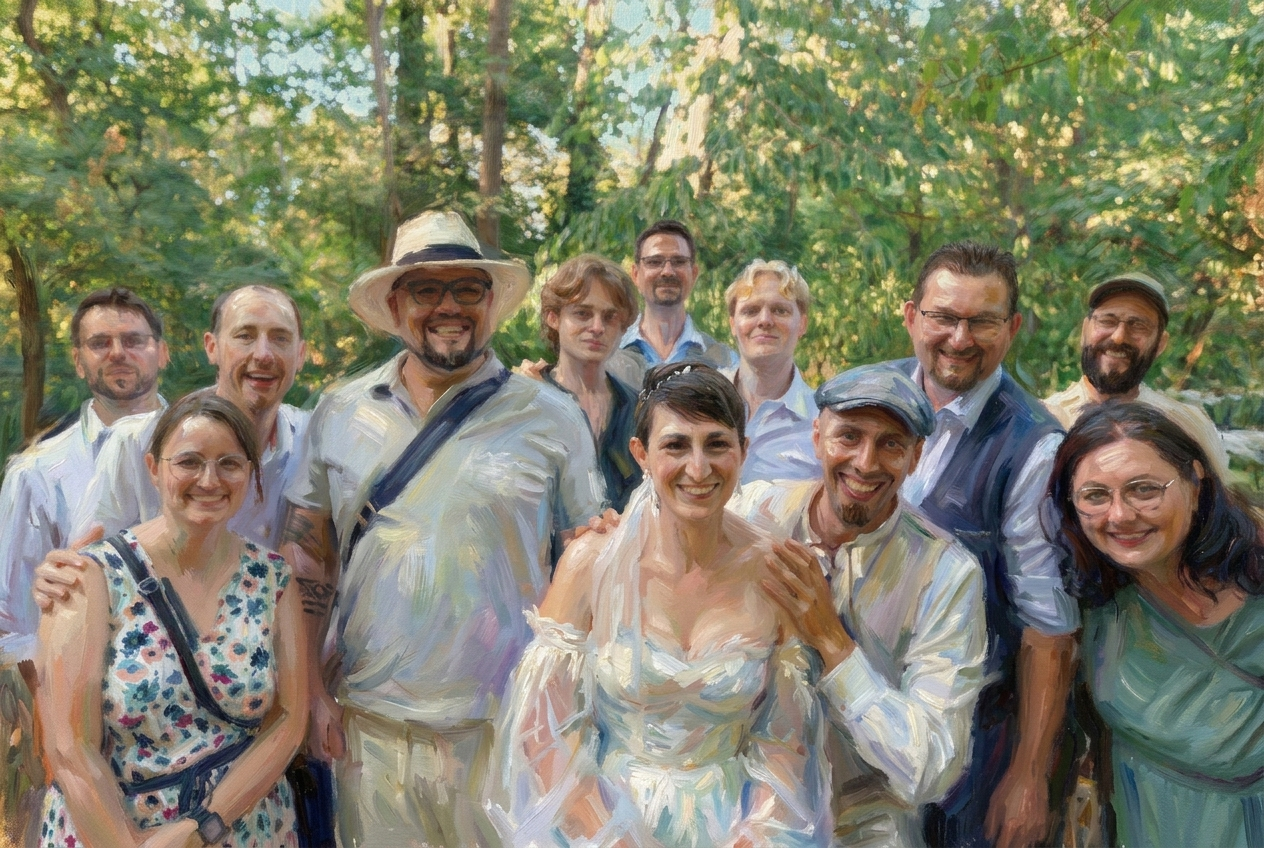

Saved to test_generations/impressionist_gemini-3.1-flash_2026-09-13_21-21-47.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Generate & Display  — matches filter_nanobanana.py logic
# ═══════════════════════════════════════════════════════════════════════════

# ── 1. Load & prepare input image (same as _image_to_base64 + _resize_image_if_needed) ──
import json

src_image = Image.open(image_path)

# Resize if needed (same as _resize_image_if_needed)
if max(src_image.size) > max_input_size:
    w, h = src_image.size
    if w > h:
        new_w, new_h = max_input_size, int((h * max_input_size) / w)
    else:
        new_h, new_w = max_input_size, int((w * max_input_size) / h)
    src_image = src_image.resize((new_w, new_h), Image.Resampling.LANCZOS)
    print(f"Resized to {src_image.size}")

# Convert to base64 (same as _image_to_base64)
fmt = input_image_format.upper()
if fmt == "JPEG" and src_image.mode in ("RGBA", "LA", "P"):
    src_image = src_image.convert("RGB")

buf = io.BytesIO()
src_image.save(buf, format=fmt)
image_b64 = base64.b64encode(buf.getvalue()).decode("utf-8")
mime_type = f"image/{input_image_format}"

# ── 2. Build payload (same as _apply_gemini_filter) ──────────────────────
image_config = {}

# Aspect ratio validation (all models support all ratios)
image_config["aspectRatio"] = aspect_ratio

# Image size validation per model
model_info = MODELS.get(model, {})
allowed_sizes = model_info.get("image_sizes", ())
if allowed_sizes:
    if image_size in allowed_sizes:
        image_config["imageSize"] = image_size
    else:
        print(f"WARNING: image_size '{image_size}' not supported by '{model}', omitting.")
else:
    print(f"INFO: Model '{model}' does not support imageSize, omitting.")

generation_config = {
    "imageConfig": image_config,
    "responseModalities": response_modalities,
}

payload = {
    "contents": [
        {
            "parts": [
                {"text": prompt},
                {
                    "inlineData": {
                        "mimeType": mime_type,
                        "data": image_b64,
                    }
                },
            ]
        }
    ],
    "generationConfig": generation_config,
}

headers = {
    "x-goog-api-key": GEMINI_API_KEY,
    "Content-Type": "application/json",
}

api_url = f"https://generativelanguage.googleapis.com/v1beta/models/{model}:generateContent"

# ── 3. Call Gemini API ────
print(f"Sending request to {model}...")
session = requests.Session()
response = session.post(api_url, headers=headers, json=payload, timeout=timeout_seconds)
session.close()

if response.status_code != 200:
    raise RuntimeError(f"Gemini API error: {response.status_code} - {response.text}")

result = response.json()

if "error" in result:
    raise RuntimeError(f"Gemini API error: {result['error'].get('message', 'Unknown error')}")

# ── 4. Extract image from response (same as production) ──────────────────
candidates = result.get("candidates", [])
if not candidates:
    raise RuntimeError(f"No candidates in response: {result}")

generated_image = None
for part in candidates[0].get("content", {}).get("parts", []):
    if "inlineData" in part:
        img_data_b64 = part["inlineData"]["data"]
        generated_image = Image.open(io.BytesIO(base64.b64decode(img_data_b64)))
        break
    elif "text" in part:
        print(f"API text response: {part['text'][:300]}")

if generated_image is None:
    print(f"Full API response: {json.dumps(result, indent=2)}")
    raise RuntimeError("No image data received from Gemini API")

print(f"Generated image: {generated_image.size}, mode={generated_image.mode}")

# ── 5. Display inline ────────────────────────────────────────────────────
display(generated_image)

# ── 6. Save to disk ──────────────────────────────────────────────────────
output_dir = "test_outputs"
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, output_filename)
generated_image.save(output_path)
print(f"Saved to {output_path}")

In [424]:
print(response.text)

{
  "candidates": [
    {
      "content": {
        "parts": [
          {
            "inlineData": {
              "mimeType": "image/jpeg",
              "data": "..."
            },
            "thoughtSignature": "..."
          }
        ],
        "role": "model"
      },
      "finishReason": "STOP",
      "index": 0
    }
  ],
  "usageMetadata": {
    "promptTokenCount": 304,
    "candidatesTokenCount": 1381,
    "totalTokenCount": 1685,
    "promptTokensDetails": [
      {
        "modality": "TEXT",
        "tokenCount": 46
      },
      {
        "modality": "IMAGE",
        "tokenCount": 258
      }
    ],
    "candidatesTokensDetails": [
      {
        "modality": "IMAGE",
        "tokenCount": 1120
      }
    ],
    "serviceTier": "standard"
  },
  "modelVersion": "gemini-3.1-flash-image",
  "responseId": "zPemasnTDqyu28oP3b6y-Ao"
}

